
# Binning and Binarization in Machine Learning

This notebook demonstrates **two important feature engineering techniques**:

1. **Binning (Discretization)**
2. **Binarization**

These techniques are used during **data preprocessing** to simplify numerical features and sometimes improve model performance.


# Import Libraries

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer, Binarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import  DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import  accuracy_score

warnings.filterwarnings("ignore")

# Import Dataset

In this notebook we will use the **Titanic dataset** to demonstrate binning techniques.

We will apply binning on numerical features such as:
- Age
- Fare

These features are continuous and can be transformed into categorical intervals using binning.

In [2]:
df = pd.read_csv("E:\Machine-Learning\ML_Preprocessing\Machine_Learning_Pipelines\\train.csv")
df.drop(columns=['PassengerId','Pclass','Sex','SibSp','Parch','Ticket','Cabin','Embarked','Name'], inplace=True)
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.dropna(inplace=True)

In [4]:
df.shape

(714, 3)

# Train Test Split

In [5]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [6]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


# Model Implementation

In [8]:
clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [9]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [10]:
np.mean(cross_val_score(clf,X_train,y_train,cv=10, scoring='accuracy'))

np.float64(0.6271324863883847)

# What is Binning?

**Binning** converts continuous numerical values into **discrete intervals (bins)**.

Instead of working with raw numbers, values are grouped into ranges.

### Example

Age values:

18, 22, 25, 35, 42, 60

After binning:

- Young → 18–25
- Adult → 26–40
- Senior → 41+

### Why Binning is Useful

- Reduces noise in data
- Simplifies complex distributions
- Helps capture non‑linear relationships
- Makes models easier to interpret


## Types of Binning
### 1. Equal Width Binning

Equal width binning divides the data range into intervals of equal size.

This can be implemented using `pd.cut()`.

In [11]:
X['Age_bin_equal_width'] = pd.cut(X['Age'], bins=3)

X[['Age', 'Age_bin_equal_width']].head()

,Age,Age_bin_equal_width
0,22.0,"(0.34, 26.947]"
1,38.0,"(26.947, 53.473]"
2,26.0,"(0.34, 26.947]"
3,35.0,"(26.947, 53.473]"
4,35.0,"(26.947, 53.473]"


### 2. Equal Frequency Binning
Equal Frequency binning ensures that each bin contains approximately the same number of observations.

This can be implemented using `pd.qcut()`.

In [12]:
X['Age_bin_equal_freq'] = pd.qcut(X['Age'], q=3)

X[['Age', 'Age_bin_equal_freq']].head()

,Age,Age_bin_equal_freq
0,22.0,"(0.419, 23.0]"
1,38.0,"(34.0, 80.0]"
2,26.0,"(23.0, 34.0]"
3,35.0,"(34.0, 80.0]"
4,35.0,"(34.0, 80.0]"


### 3. Custom Binning
Sometimes bins are defined manually based on domain knowledge.

For Example:

Age groups :-
-  Child
- Adult
- Senior

In [13]:
bins= [0,18,40,100]
labels = ['Child','Adult','Senior']

X['Age_group'] = pd.cut(X["Age"], bins=bins, labels=labels)

X[["Age", "Age_group"]].sample(5)

,Age,Age_group
139,24.0,Adult
132,47.0,Senior
779,43.0,Senior
269,35.0,Adult
20,35.0,Adult


## KBinsDisretizer
KBinsDisretizer is a Scikit-Learn preprocessing tool that  converts continuous features into discrete bins.

It supports three strategies:
- uniform --> equal width bins
- quantile --> equal frequency bins
- kmeans --> bins based on clustering


In [14]:
kb_uniform = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='uniform')
kb_quantile   = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='quantile')
kb_kmeans  = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='kmeans')


### 1. Uniform Strategy


In [15]:
X['Age_uniform'] = kb_uniform.fit_transform(X[['Age']].fillna(X['Age'].mean()))

X[["Age", "Age_uniform"]].sample(5)

,Age,Age_uniform
770,24.0,1.0
851,74.0,4.0
230,35.0,2.0
406,51.0,3.0
398,23.0,1.0


If we want to see the intervals/range the we use `bins_edges_`.

The `bins_edges_` attributes of `KBinsDiscretize` stores the boundaries of each bin. These boundaries can be used to create human-readable interval labels with their starting points,

In [16]:
edges = kb_uniform.bin_edges_[0]
print("Bin Intervals of kb_uniform")
for i in range(len(edges)-1):
    print(f"{edges[i]:.2f} - {edges[i+1]:.2f}")

Bin Intervals of kb_uniform
0.42 - 16.34
16.34 - 32.25
32.25 - 48.17
48.17 - 64.08
64.08 - 80.00


### 2. Quantile Strategy

In [17]:
X["Age_quantile"] = kb_quantile.fit_transform(X[['Age']].fillna(X['Age'].mean()))

X[["Age", "Age_quantile"]].sample(5)

,Age,Age_quantile
627,21.0,1.0
879,56.0,4.0
769,32.0,3.0
371,18.0,0.0
765,51.0,4.0


In [18]:
edges = kb_quantile.bin_edges_[0]
print("Bin Intervals of kb_quantile")
for i in range(len(edges)-1):
    print(f"{edges[i]:.2f} - {edges[i+1]:.2f}")

Bin Intervals of kb_quantile
0.42 - 19.00
19.00 - 25.00
25.00 - 31.80
31.80 - 41.00
41.00 - 80.00


### 3. Kmeans Strategy

In [19]:
X["Age_kmeans"] = kb_kmeans.fit_transform(X[['Age']].fillna(X['Age'].mean()))

X[["Age", "Age_kmeans"]].sample(5)

,Age,Age_kmeans
398,23.0,1.0
131,20.0,1.0
882,22.0,1.0
550,17.0,1.0
38,18.0,1.0


In [20]:
edges = kb_kmeans.bin_edges_[0]
print("Bin Intervals of kb_kmeans")
for i in range(len(edges)-1):
    print(f"{edges[i]:.2f} - {edges[i+1]:.2f}")

Bin Intervals of kb_kmeans
0.42 - 13.16
13.16 - 27.01
27.01 - 39.40
39.40 - 54.04
54.04 - 80.00


## Model implementation
So we create a function which contains **KBinsDiscretizer, columntransformer, cross_val_score, and visualizaation**

In [21]:
def discritize(bins, strategy):

    kbins_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbins_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer(
        transformers=[
            ('first', kbins_age, [0]),
            ('second', kbins_fare, [1])
        ]
    )

    X_trf = trf.fit_transform(X_train)

    print(np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y_train, cv=10, scoring='accuracy')))

    cols = ['Age','Fare']

    for i, col in enumerate(cols):

        plt.figure(figsize=(14,4))

        plt.subplot(1,2,1)
        plt.hist(X_train[col])
        plt.title("Before")

        plt.subplot(1,2,2)
        plt.hist(X_trf[:, i], color='red')
        plt.title("After")

        plt.show()

we call that function with different strategy for understanding all techniques and how it effect on the data/ features.

0.6777979431336962


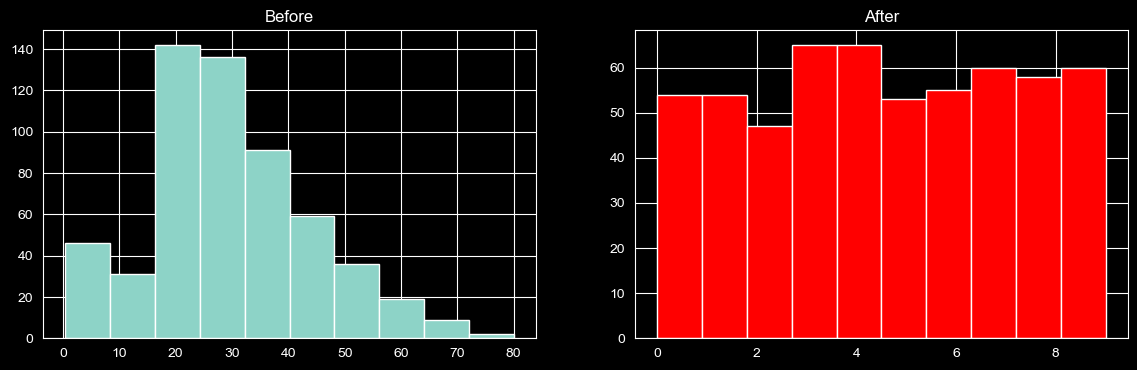

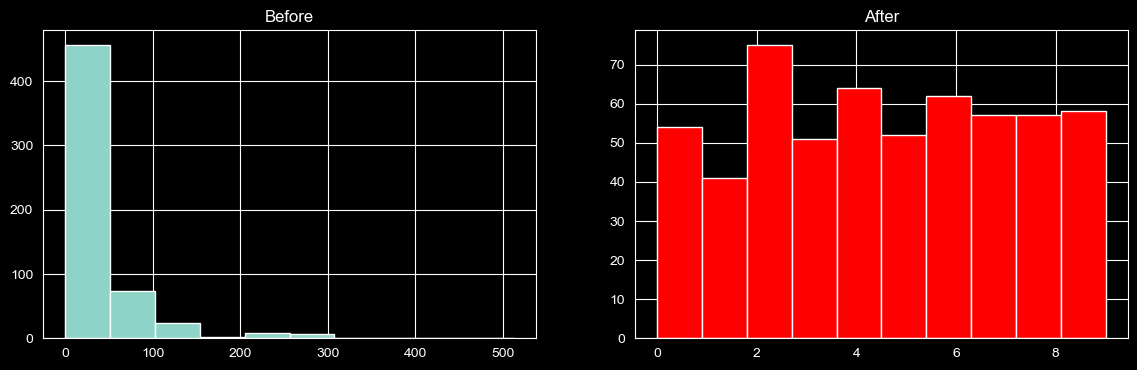

In [22]:
discritize(10,'quantile')

0.6374470659407139


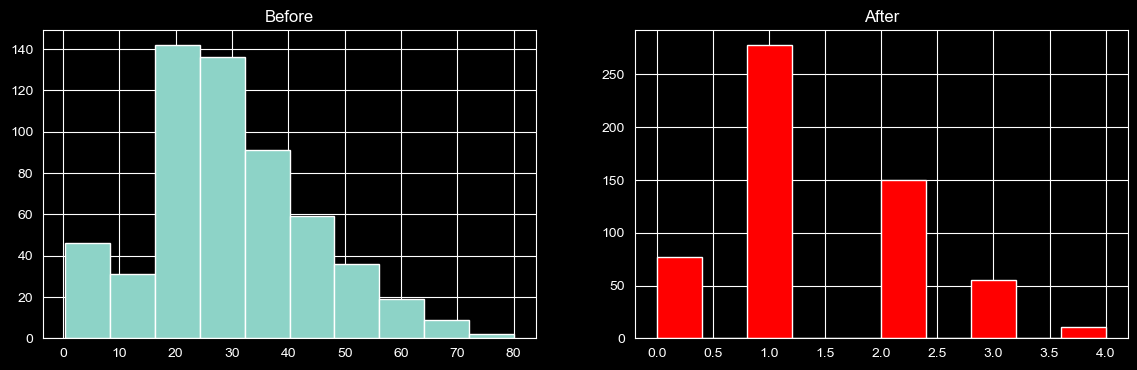

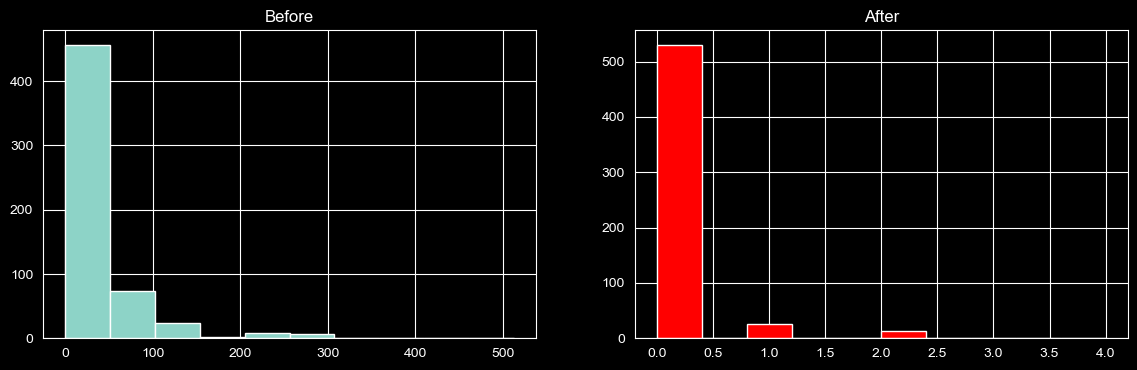

In [23]:
discritize(5,'uniform')

0.6881730187537809


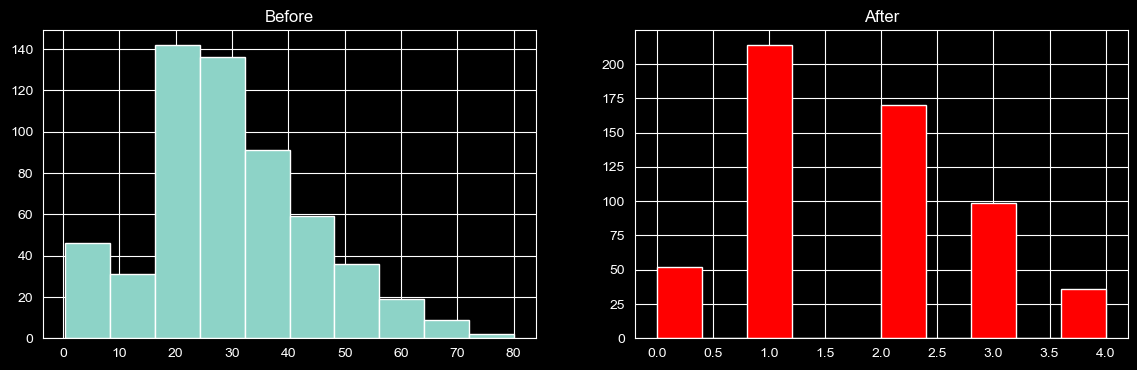

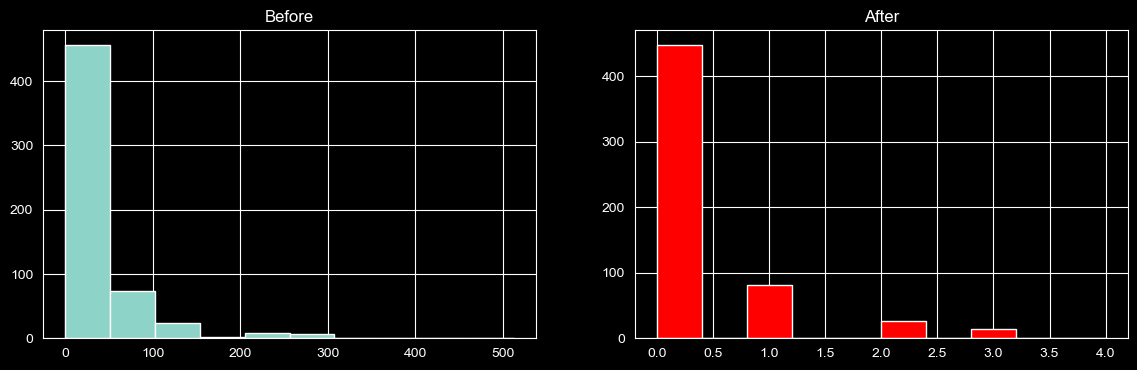

In [24]:
discritize(5,'kmeans')

### Observation
So the `cross_val_score :` is *0.6253* without Binning

the `cross_val_score :` after binning on different strategy are
- uniform : 0.6374
- kmeans : 0.6881
- quantity : 0.6777

# What is Binarization ?
**Binarization** converts numerical values into **binary values (0 or 1)** based on a threshold.
Values above the threshold become 1, and values below the threshold become 0.

In [31]:
df_b = pd.read_csv("E:\Machine-Learning\ML_Preprocessing\Machine_Learning_Pipelines\\train.csv",usecols=["Age",'Fare','Survived','SibSp','Parch'])

df_b.dropna(inplace=True)

df_b.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [32]:
Xb = df_b.iloc[:,1:]
yb = df_b.iloc[:,0]

## Binarization Example (Threshold based)

We do Binarization by `sklearn.preprocessing.Binarize` and other is `np.where`. This two class are use to perform binarization

1. By Sklearn.preprocessing.Binarize

In [33]:
binarizer = Binarizer(threshold=30)

Xb["Age"] = binarizer.fit_transform(Xb[["Age"]])

**observation : we observe that after the binarization on `Age` column we get two value 0 and 1. So the age greater than 30 come under 1 category and rest all or say that less than comes under 30**

In [34]:
Xb["Age"].value_counts()

Age
0.0    409
1.0    305
Name: count, dtype: int64

In [35]:
Xb["Fare"].value_counts()

Fare
13.0000    41
26.0000    30
8.0500     29
10.5000    24
7.8958     23
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 220, dtype: int64

**Observation : In  `Fare` column the *min fare is 0* and *max fare is 512.32*, and most frequent value is 13.00 so we take this as threshold.**

2. By np.where
- In this I use Fare column and my threshold is `13.00`

In [36]:
np.where(Xb["Fare"] > 13.00, 1,0)

array([0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,

## Model Evaluation
So now I implement a `DecisionClassifierTree` for predict the survived on the basis of family

So what I do :
1. Predict value without Binarization.
2. Feature Creation by adding `SibSp` and `Parch` and create `family` column.
3. Drop both the columns
4. Use column_transformer and apply Binarization on `family`.
5. Then again apply model

In [30]:
def binarize_model(Xb, yb):
